# Proyecto UD4
#### UD4. Redes Neuronais
#### MP. Sistemas de Aprendizaxe Automáticos
#### IES de Teis (Vigo),Vanesa Resúa Eiras, Cristina Gómez Alonso


### Datasets de Clasificación: Cristales vs Crédito

Para este proyecto os doy opción a que escojáis entre dos datasets diferentes.
El primero no os exigirá ningún preprocesado previo, mientras que el segundo sí.
Por otro lado, el primero es clasificación multiclase, mientras que el segundo es de clasificación binaria.
La calificación máxima en caso de que escojáis el primero será de 8 puntos mientras que si escojéis el segundo será de 10 puntos.

#### Dataset Crédito

Disponemos de un dataset con 1000 instancias clasificadas en 2 tipos diferentes de clientes: a los que se les otorga un crédito y a los que no.

Lista de atributos para cada entrada será:

* checking_status: estado de la cuenta corriente existente, en marcos alemanes.
* duration: duración en meses
* credit_history: historial crediticio (créditos tomados, reembolsados debidamente, atrasos, cuentas críticas)
* purpose: finalidad del crédito (coche, televisión,…)
* credit_amount: cantidad solicitada de crédito
* saving_status: estado de su cuenta de ahorro/bonos, en marcos alemanes.
* employment: empleo actual en número de años.
* installament_commitment: tasa de cuota en porcentaje de ingresos disponibles
* personal_status: estado personal (casado, soltero,…) y sexo
* other_parties: otros deudores / garantes
* residence_since: residencia actual desde hace X años
* property_magnitude: propiedades (por ejemplo, casas, pisos...)
* age: Edad en años
* other_payment_plans: otros planes de cuotas (bancos, tiendas)
* housing: vivienda (alquiler, propia,…)
* existing_credits: número de créditos existentes con esta entidad
* job: trabajo
* num_dependents: número de personas dependientes o a las que proporcionan manuntención
* own_phone: teléfono (yes, no)
* foreign_worker: trabajador extranjero (yes, no)
* class: clase: good (crédito otorgado), bad (crédito denegado)

Escoge uno de los dos datasets anteriores y resuelve los siguientes apartados.

## 1. Importación del dataset

In [1]:
import os
import warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 
warnings.filterwarnings("ignore")

import math

import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, balanced_accuracy_score, f1_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)

In [2]:
creditos = pd.read_csv('credits.csv')
creditos

,ID,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,vty,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,dkl,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,bwf,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,qln,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,uzh,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,...,no known property,53,none,for free,2,skilled,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,jlf,no checking,12,existing paid,furniture/equipment,1736,<100,4<=X<7,3,female div/dep/mar,...,real estate,31,none,own,1,unskilled resident,1,none,yes,good
996,imr,<0,30,existing paid,used car,3857,<100,1<=X<4,4,male div/sep,...,life insurance,140,none,own,1,high qualif/self emp/mgmt,1,yes,yes,good
997,xnt,no checking,12,existing paid,radio/tv,804,<100,>=7,4,male single,...,car,38,none,own,1,skilled,1,none,yes,good
998,egn,<0,45,existing paid,radio/tv,1845,<100,1<=X<4,4,male single,...,no known property,23,none,for free,1,skilled,1,yes,yes,bad


## 2. EDA&Preprocessing (2 puntos crédito, 1 punto cristales)

In [3]:
print(f"Nuestro dataframe tiene {creditos.shape[0]} filas y {creditos.shape[1]} columnas")


Nuestro dataframe tiene 1000 filas y 22 columnas


In [4]:
creditos.describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.746000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,12.367961,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,149.000000,4.000000,2.000000


In [5]:
creditos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ID                      999 non-null    object
 1   checking_status         1000 non-null   object
 2   duration                1000 non-null   int64 
 3   credit_history          1000 non-null   object
 4   purpose                 1000 non-null   object
 5   credit_amount           1000 non-null   int64 
 6   savings_status          1000 non-null   object
 7   employment              1000 non-null   object
 8   installment_commitment  1000 non-null   int64 
 9   personal_status         1000 non-null   object
 10  other_parties           1000 non-null   object
 11  residence_since         1000 non-null   int64 
 12  property_magnitude      1000 non-null   object
 13  age                     1000 non-null   int64 
 14  other_payment_plans     1000 non-null   object
 15  housi

<div style="font-family: Arial, sans-serif; line-height: 1.6; color: #333;">

El dataset original cuenta con 1000 registros y 22 columnas. Contiene 15 variables categóricas (tipo object) que requerirán transformación, y se aprecian datos faltantes en las columnas ID y own_telephone


</div>

In [6]:
print(f"Valores duplicados: {creditos.duplicated().sum()}")

Valores duplicados: 0


In [7]:
creditos.isnull().sum()

ID                         1
checking_status            0
duration                   0
credit_history             0
purpose                    0
credit_amount              0
savings_status             0
employment                 0
installment_commitment     0
personal_status            0
other_parties              0
residence_since            0
property_magnitude         0
age                        0
other_payment_plans        0
housing                    0
existing_credits           0
job                        0
num_dependents             0
own_telephone             10
foreign_worker             0
class                      0
dtype: int64

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Se observa la presencia de valores nulos en dos columnas:
</p>

<ul>
    <li>La columna <code style="color:#0b5394;">id</code> presenta <strong>1 valor nulo</strong>.</li>
    <li>La columna <code style="color:#0b5394;">own_telephone</code> contiene <strong>10 valores nulos</strong>.</li>
</ul>

<p>
Aunque la cantidad de valores faltantes es reducida, será importante considerarlos en el análisis posterior.
</p>

</div>

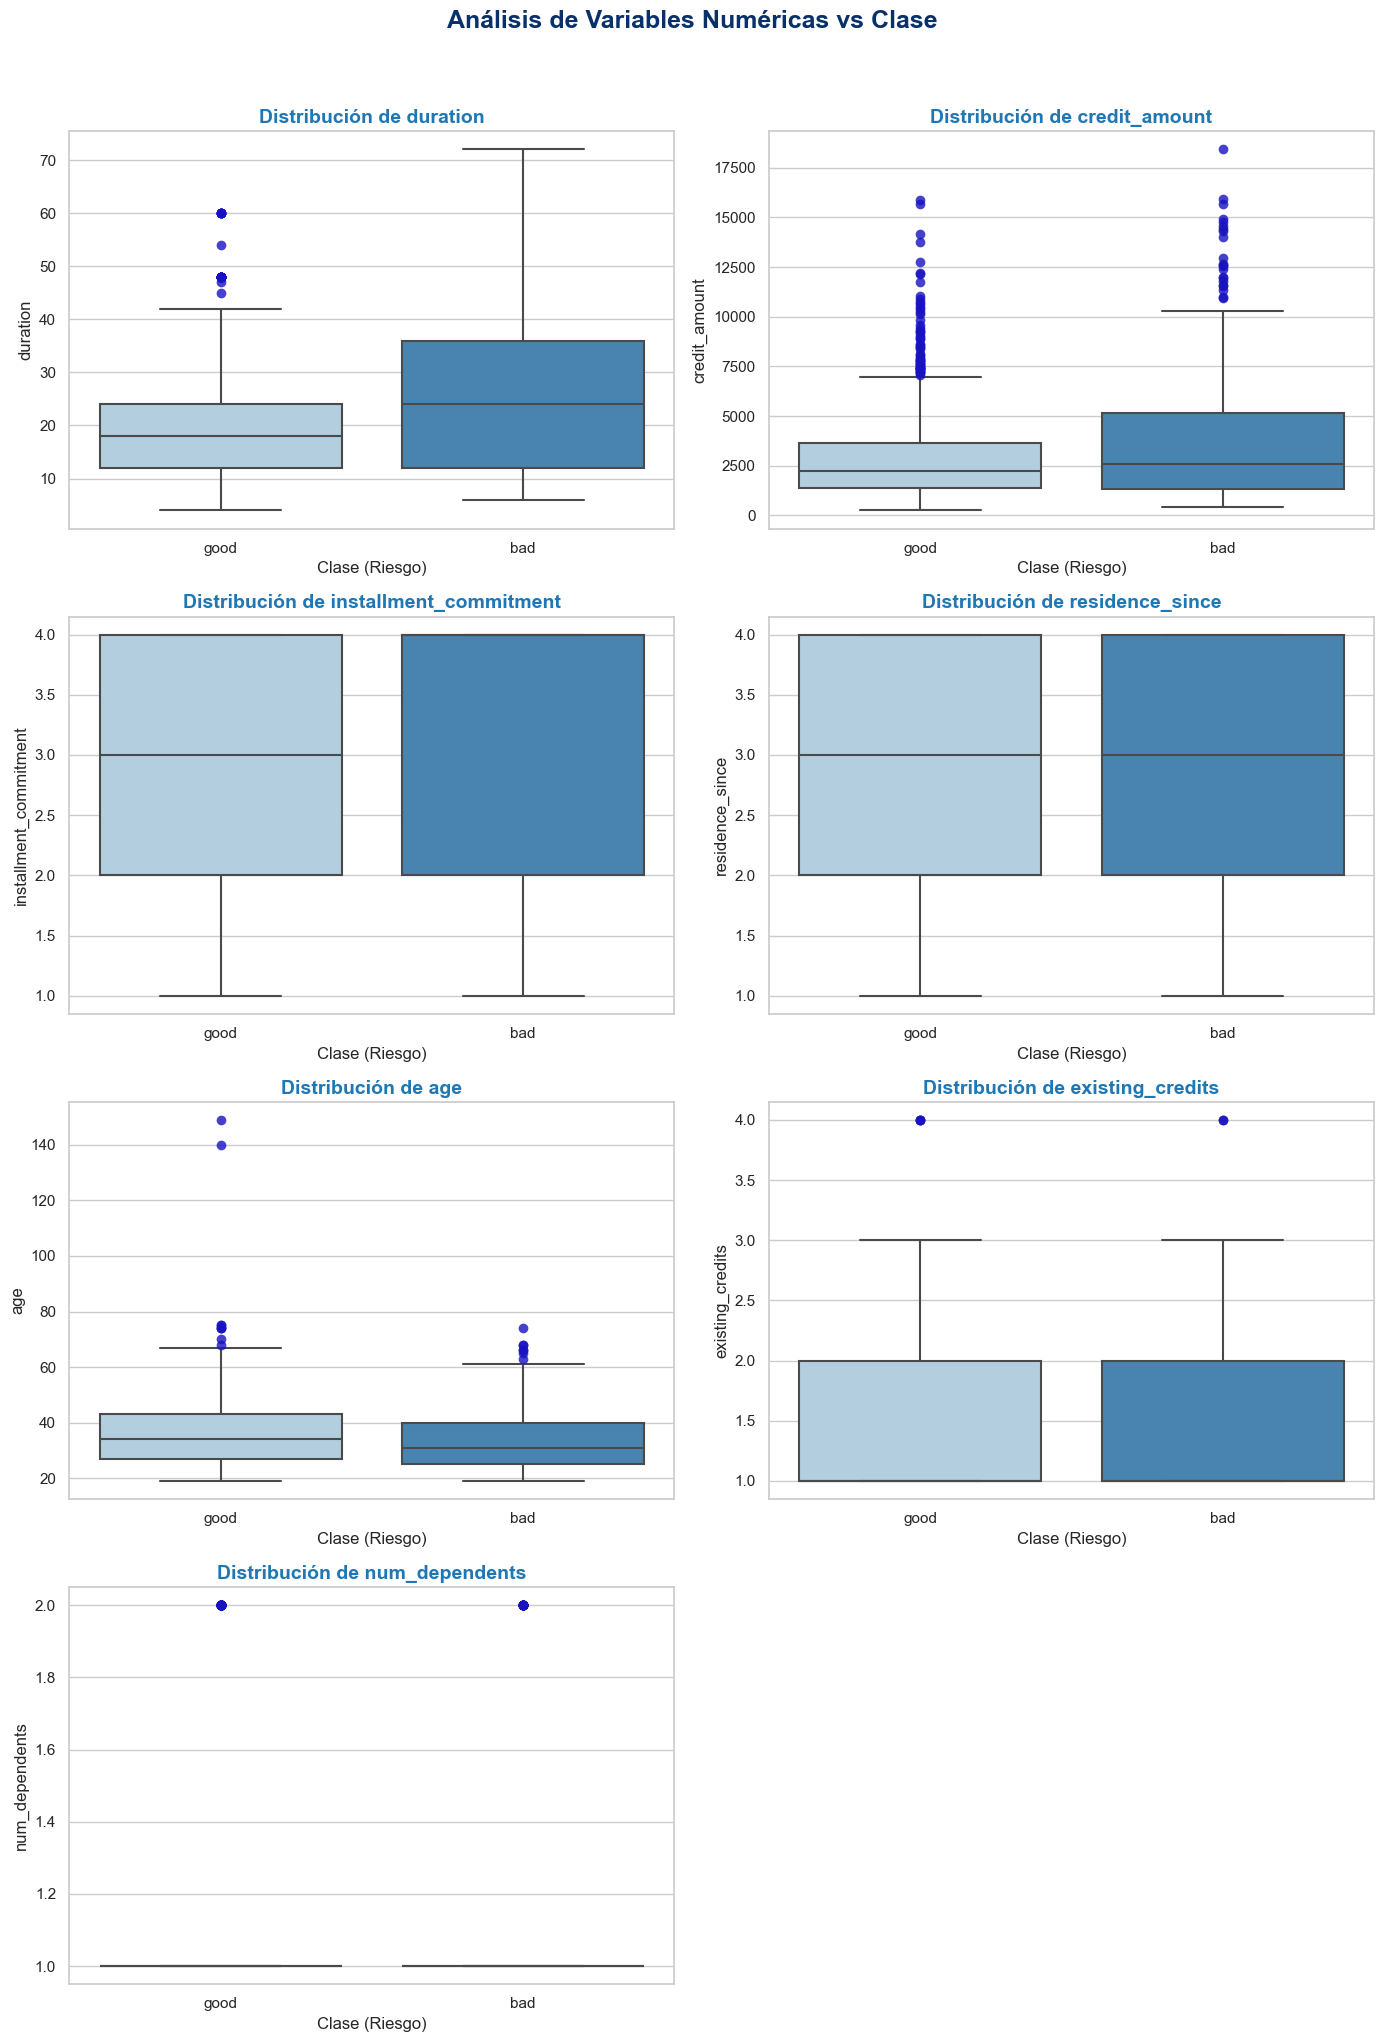

In [8]:
num_cols = creditos.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)

cols = 2
rows = math.ceil(n_cols / cols)

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten()

outlier_props = dict(markerfacecolor="#1812c0", marker='o', markersize=7, alpha=0.8, markeredgecolor='none')

for i, var in enumerate(num_cols):
    sns.boxplot(
        x='class', 
        y=var, 
        data=creditos, 
        ax=axes[i], 
        palette="Blues",       
        flierprops=outlier_props,
        linewidth=1.5
    )
    axes[i].set_title(f'Distribución de {var}', fontsize=14, fontweight='bold', color='#1f77b4')
    axes[i].set_xlabel('Clase (Riesgo)', fontsize=12)
    axes[i].set_ylabel(var, fontsize=12)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Análisis de Variables Numéricas vs Clase', 
             fontsize=18, fontweight='bold', color='#08306b', y=1.02)
plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
El análisis visual de las variables numéricas frente a la clase revela lo siguiente:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Importe y duración:</strong> Los créditos denegados (<code style="color:#0b5394;">bad</code>) suelen asociarse a plazos de devolución más largos y montos de dinero mayores.
    </li>
    <li>
        <strong>Edad:</strong> Existe una ligera tendencia a mayor morosidad en clientes más jóvenes.
    </li>
    <li>
        <strong>Valores atípicos (Outliers):</strong> Se observan registros poco realistas, como clientes con edades cercanas a los 150 años, lo que confirma la necesidad de un preprocesamiento adecuado.
    </li>
</ul>

</div>

In [9]:

# Extraemos las edades en formato lista para cada categoría
df_good = creditos.loc[creditos["class"] == 'good']['age'].values.tolist()
df_bad = creditos.loc[creditos["class"] == 'bad']['age'].values.tolist()
df_age = creditos['age'].values.tolist()

#  Configurar histogramas:
#  Buen crédito (Good)
trace0 = go.Histogram(
    x=df_good,
    histnorm='probability',
    name="Buen Crédito (Good)",
    marker_color='#2ca02c', # Tono verde
    opacity=0.7
)

# Mal crédito (Bad)
trace1 = go.Histogram(
    x=df_bad,
    histnorm='probability',
    name="Mal Crédito (Bad)",
    marker_color='#d62728', # Tono rojo
    opacity=0.7
)

# Distribución general
trace2 = go.Histogram(
    x=df_age,
    histnorm='probability',
    name="Distribución General",
    marker_color='#1f77b4', # Tono azul
    opacity=0.7
)


fig = make_subplots(
    rows=2, cols=2, 
    specs=[[{}, {}], [{'colspan': 2}, None]],
    subplot_titles=('Distribución Buen Crédito', 'Distribución Mal Crédito', 'Distribución General de Edades')
)

fig.add_trace(trace0, row=1, col=1)
fig.add_trace(trace1, row=1, col=2)
fig.add_trace(trace2, row=2, col=1)

fig.update_layout(
    showlegend=True, 
    title_text='Análisis de Distribución de Edades', 
    bargap=0.05,
    height=600,
    template='plotly_white'
)

fig.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Como se observa en la gráfica de la variable <strong>edad</strong>, la mayor concentración de solicitantes se sitúa entre los 25 y 30 años.
</p>

<p>
Este patrón se presenta tanto en los créditos concedidos como en los denegados, lo que indica que la distribución de edad es similar en ambas clases.
</p>

<p>
Por tanto, no se puede considerar la edad como un factor discriminante por sí sola, sino como una característica con bajo poder predictivo individual.
</p>

<p>
Este comportamiento refuerza la necesidad de utilizar modelos más complejos, como redes neuronales, capaces de capturar relaciones no lineales y patrones ocultos entre múltiples variables.
</p>

</div>

In [10]:

cuenta_riesgo = creditos.groupby(['checking_status', 'class']).size().reset_index(name='count')

cuenta_riesgo['porcentaje'] = cuenta_riesgo.groupby('checking_status')['count'].transform(lambda x: x / x.sum() * 100)

cuenta_riesgo['class'] = cuenta_riesgo['class'].map({'good': 'Buen Crédito', 'bad': 'Mal Crédito'})

fig2 = px.bar(
    cuenta_riesgo, 
    x='checking_status', 
    y='porcentaje', 
    color='class',
    barmode='group',
    color_discrete_map={'Buen Crédito': "#0400fd", 'Mal Crédito': "#72a5de"},
    labels={'checking_status': 'Estado de la Cuenta Corriente', 'porcentaje': 'Porcentaje (%)', 'class': 'Tipo de Riesgo'},
    title='Riesgo según el Estado de la Cuenta Corriente'
)

fig2.update_layout(template='plotly_white', height=500)
fig2.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La variable <strong>estado de la cuenta</strong> (<code style="color:#0b5394;">checking_status</code>) presenta un alto poder predictivo.
</p>

<p>
Los clientes sin cuenta corriente o con saldos positivos (≥ 200) muestran una tasa de créditos satisfactorios superior al 80%.
</p>

<p>
En contraste, aquellos con saldo negativo (&lt; 0) representan el grupo de mayor riesgo, alcanzando niveles de morosidad cercanos al 50%.
</p>

</div>

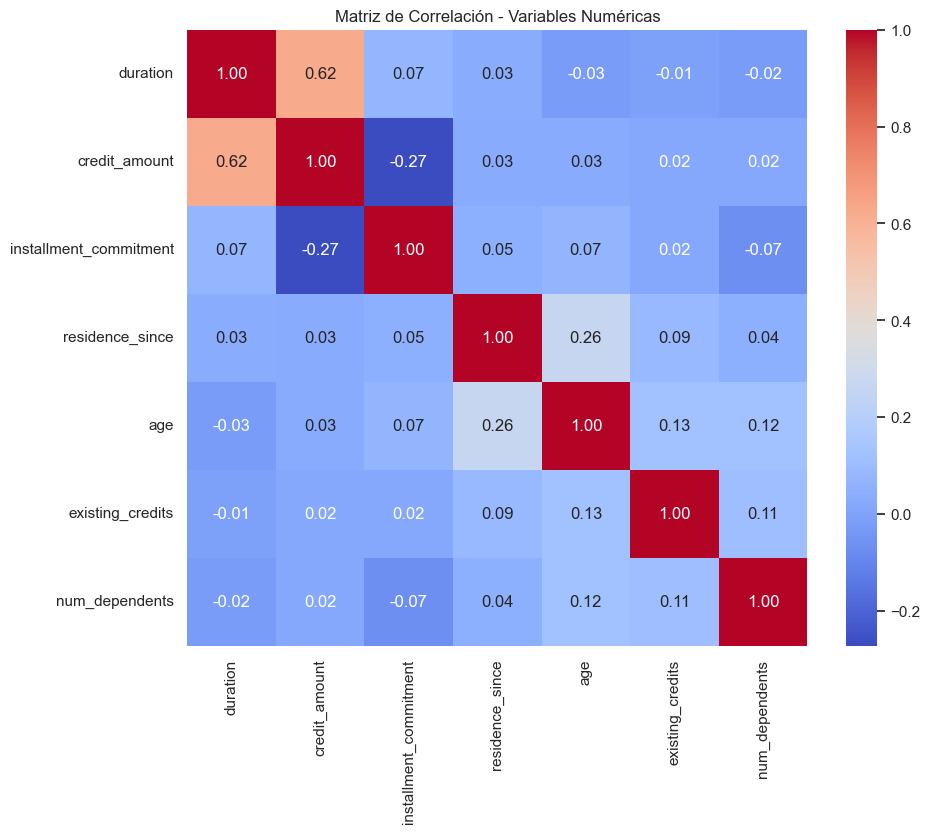

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(creditos[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación - Variables Numéricas')
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La relación más relevante del conjunto de datos es la correlación positiva entre <code style="color:#0b5394;">duration</code> y <code style="color:#0b5394;">credit_amount</code> (0.62).
</p>

<p>
Este resultado indica que los préstamos de mayor importe suelen asociarse a plazos de devolución más largos, lo cual es coherente desde el punto de vista financiero.
</p>

<p>
Asimismo, se observa una correlación negativa moderada entre <code style="color:#0b5394;">credit_amount</code> e <code style="color:#0b5394;">installment_commitment</code> (-0.27).
</p>

<p>
Esto sugiere que, ante importes elevados, las entidades tienden a ajustar las condiciones del crédito para reducir el impacto de la cuota mensual sobre los ingresos del cliente.
</p>

<p>
Por último, a nivel demográfico, se identifica una correlación positiva leve entre <code style="color:#0b5394;">age</code> y <code style="color:#0b5394;">residence_since</code> (0.26), lo que refleja una mayor estabilidad residencial en clientes de mayor edad.
</p>

</div>

### PREPROCESAMIENTO

In [12]:
creditos_prep = creditos.copy()

creditos_prep = creditos_prep.drop('ID', axis=1)

moda_telefono = creditos_prep['own_telephone'].mode()[0]
creditos_prep['own_telephone'] = creditos_prep['own_telephone'].fillna(moda_telefono)

creditos_prep['class'] = creditos_prep['class'].map({'good': 1, 'bad': 0})



<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Se aplican las siguientes transformaciones en la fase de preprocesamiento:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Eliminación de <code style="color:#0b5394;">id</code>:</strong> Al tratarse de un identificador único, no aporta valor predictivo al modelo.
    </li>
    <li>
        <strong>Imputación de <code style="color:#0b5394;">own_telephone</code>:</strong> Los valores nulos se reemplazan por la moda. Dado el tamaño reducido del conjunto de datos, se evita la eliminación de registros para no perder información relevante.
    </li>
    <li>
        <strong>Codificación de <code style="color:#0b5394;">class</code>:</strong> La variable objetivo se transforma a formato binario (<code style="color:#0b5394;">good = 1</code>, <code style="color:#0b5394;">bad = 0</code>).
    </li>
</ul>

</div>

In [13]:
# Separación de características (Features) y variable objetivo (Target)

X = creditos_prep.drop('class', axis=1)
y = creditos_prep['class'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=seed, 
    stratify=y  # Mantiene la proporción de clases
)

# One-Hot Encoding sin fuga de información (se ajusta en train y se alinea test)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Las variables categóricas se transforman mediante <strong>One-Hot Encoding</strong>, generando representaciones binarias para cada categoría.
</p>

<p>
Al emplear el parámetro <code style="color:#0b5394;">drop_first = True</code>, se evita la multicolinealidad y se reduce la dimensionalidad del conjunto de datos.
</p>

<p>
Este enfoque contribuye a mejorar la estabilidad del modelo y a mitigar el riesgo de sobreajuste (<em>overfitting</em>).
</p>

</div>

In [14]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- Resumen del Preprocesamiento ---")
print(f"Dimensiones del conjunto de Entrenamiento (X_train_scaled): {X_train_scaled.shape}")
print(f"Dimensiones del conjunto de Prueba (X_test_scaled): {X_test_scaled.shape}")
print(f"Proporción de la clase positiva en Train: {y_train.mean():.2f}")
print(f"Proporción de la clase positiva en Test: {y_test.mean():.2f}")

--- Resumen del Preprocesamiento ---
Dimensiones del conjunto de Entrenamiento (X_train_scaled): (800, 48)
Dimensiones del conjunto de Prueba (X_test_scaled): (200, 48)
Proporción de la clase positiva en Train: 0.70
Proporción de la clase positiva en Test: 0.70


## 3. Creación RRNN, entrenamientos, evaluaciones, predicciones y representación gráfica (4 puntos crédito, 3 puntos cristales)

In [15]:
n_features = X_train_scaled.shape[1]

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
La arquitectura del modelo se define a partir de los siguientes componentes:
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Capas densas:</strong> Adecuadas para datos tabulares, permiten modelar relaciones complejas mediante la conexión completa entre neuronas.
    </li>
    <li>
        <strong>Función de activación (ReLU):</strong> Computacionalmente eficiente y capaz de mitigar el problema del desvanecimiento del gradiente.
    </li>
    <li>
        <strong>Capa de salida y función de pérdida:</strong> Se utiliza una activación <em>sigmoid</em> para obtener probabilidades en el rango [0,1], junto con <em>binary_crossentropy</em>, adecuada para problemas de clasificación binaria.
    </li>
    <li>
        <strong>Optimizador (Adam):</strong> Ajusta dinámicamente la tasa de aprendizaje, favoreciendo una convergencia más rápida y estable.
    </li>
    <li>
        <strong>Regularización (Dropout):</strong> Se desactiva aleatoriamente un 10% de las neuronas durante el entrenamiento para mejorar la generalización y reducir el riesgo de sobreajuste.
    </li>
</ul>

<p>
Se omite el uso de <em>Batch Normalization</em> debido a la posible inestabilidad que puede generar en conjuntos de datos de tamaño reducido.
</p>

</div>

Modelo 1

In [16]:
model_1 = Sequential(name="Red_Simple")
# Capa oculta con 32 neuronas
model_1.add(Dense(32, activation='relu', input_shape=(n_features,)))
# Capa de salida binaria
model_1.add(Dense(1, activation='sigmoid'))

model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_1.summary()

Model: "Red_Simple"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,601 (6.25 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 0 (0.00 B)

Modelo 2

In [17]:
model_2 = Sequential(name="Red_Compleja")

# Primera capa oculta (Quitamos BatchNormalization que mete ruido en datasets pequeños)
model_2.add(Dense(64, activation='relu', input_shape=(n_features,)))
model_2.add(Dropout(0.1)) 

# Segunda capa oculta
model_2.add(Dense(32, activation='relu'))
model_2.add(Dropout(0.1))

# Capa de salida binaria
model_2.add(Dense(1, activation='sigmoid'))

# adam -> 0.0005 para que la red no dé pasos tan grandes y no colapse hacia la clase minoritaria.
optimizador_suave = tf.keras.optimizers.Adam(learning_rate=0.0005)

model_2.compile(optimizer=optimizador_suave, loss='binary_crossentropy', metrics=['accuracy'])
model_2.summary()

Model: "Red_Compleja"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,249 (20.50 KB)

 Trainable params: 5,249 (20.50 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
El número de parámetros en una capa densa se calcula como:
</p>

<p style="text-align: center; font-size: 15px;">
P = (N<sub>in</sub> × N<sub>out</sub>) + N<sub>out</sub>
</p>

<p>
Este cálculo considera tanto los pesos como los términos de sesgo asociados a cada neurona.
</p>

<ul style="margin-top: 8px;">
    <li>
        <strong>Modelo 1 (Simple):</strong> Cuenta con 1,601 parámetros, suficientes para capturar patrones básicos sin incurrir en una complejidad excesiva.
    </li>
    <li>
        <strong>Modelo 2 (Complejo):</strong> Aumenta a 5,249 parámetros al incrementar el número de neuronas, lo que mejora su capacidad de aprendizaje pero también incrementa el riesgo de sobreajuste.
    </li>
</ul>

<p>
<strong>Estrategia de entrenamiento:</strong>
</p>

<p>
Dado el tamaño reducido del conjunto de datos, el uso de un número fijo de épocas puede resultar inadecuado. Por ello, se establece un límite máximo de 150 épocas junto con la técnica de <em>Early Stopping</em>.
</p>

<p>
Si la métrica de validación (<code style="color:#0b5394;">val_loss</code>) no mejora durante 25 épocas consecutivas, el entrenamiento se detiene automáticamente y se restauran los mejores pesos obtenidos.
</p>

</div>

In [18]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=25, 
    restore_best_weights=True
)

class_weight_values = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weight_values))
print(f"Pesos de clase usados en entrenamiento: {class_weight_dict}")

print("Entrenando Modelo 1 (Simple)...")
history_1 = model_1.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=0
)
print(f"Modelo 1 detenido en la época {len(history_1.epoch)} por Early Stopping.")

print("\nEntrenando Modelo 2 (Complejo)...")
history_2 = model_2.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=0
)
print(f"Modelo 2 detenido en la época {len(history_2.epoch)} por Early Stopping.")

loss_1, acc_1 = model_1.evaluate(X_test_scaled, y_test, verbose=0)
loss_2, acc_2 = model_2.evaluate(X_test_scaled, y_test, verbose=0)

y_prob_1 = model_1.predict(X_test_scaled, verbose=0).ravel()
y_prob_2 = model_2.predict(X_test_scaled, verbose=0).ravel()
y_pred_class_1 = (y_prob_1 >= 0.5).astype(int)
y_pred_class_2 = (y_prob_2 >= 0.5).astype(int)

print("\n--- Resultados de Evaluación en Test (20%) ---")
for name, y_prob, y_pred, loss, acc in [
    ("Modelo 1 (Simple)", y_prob_1, y_pred_class_1, loss_1, acc_1),
    ("Modelo 2 (Complejo)", y_prob_2, y_pred_class_2, loss_2, acc_2)
]:
    print(
        f"{name} -> Loss: {loss:.4f} | Accuracy: {acc*100:.2f}% | "
        f"Balanced Acc: {balanced_accuracy_score(y_test, y_pred):.4f} | "
        f"F1 clase 0: {f1_score(y_test, y_pred, pos_label=0):.4f} | "
        f"Recall clase 0: {recall_score(y_test, y_pred, pos_label=0):.4f} | "
        f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}"
    )
    print(classification_report(y_test, y_pred, digits=4))

Pesos de clase usados en entrenamiento: {np.int64(0): np.float64(1.6666666666666667), np.int64(1): np.float64(0.7142857142857143)}
Entrenando Modelo 1 (Simple)...
Modelo 1 detenido en la época 60 por Early Stopping.

Entrenando Modelo 2 (Complejo)...
Modelo 2 detenido en la época 25 por Early Stopping.

--- Resultados de Evaluación en Test (20%) ---
Modelo 1 (Simple) -> Loss: 0.6207 | Accuracy: 68.50% | Balanced Acc: 0.6607 | F1 clase 0: 0.5333 | Recall clase 0: 0.6000 | ROC-AUC: 0.7423
              precision    recall  f1-score   support

           0     0.4800    0.6000    0.5333        60
           1     0.8080    0.7214    0.7623       140

    accuracy                         0.6850       200
   macro avg     0.6440    0.6607    0.6478       200
weighted avg     0.7096    0.6850    0.6936       200

Modelo 2 (Complejo) -> Loss: 0.6458 | Accuracy: 64.50% | Balanced Acc: 0.6036 | F1 clase 0: 0.4580 | Recall clase 0: 0.5000 | ROC-AUC: 0.6506
              precision    recall  f1-s

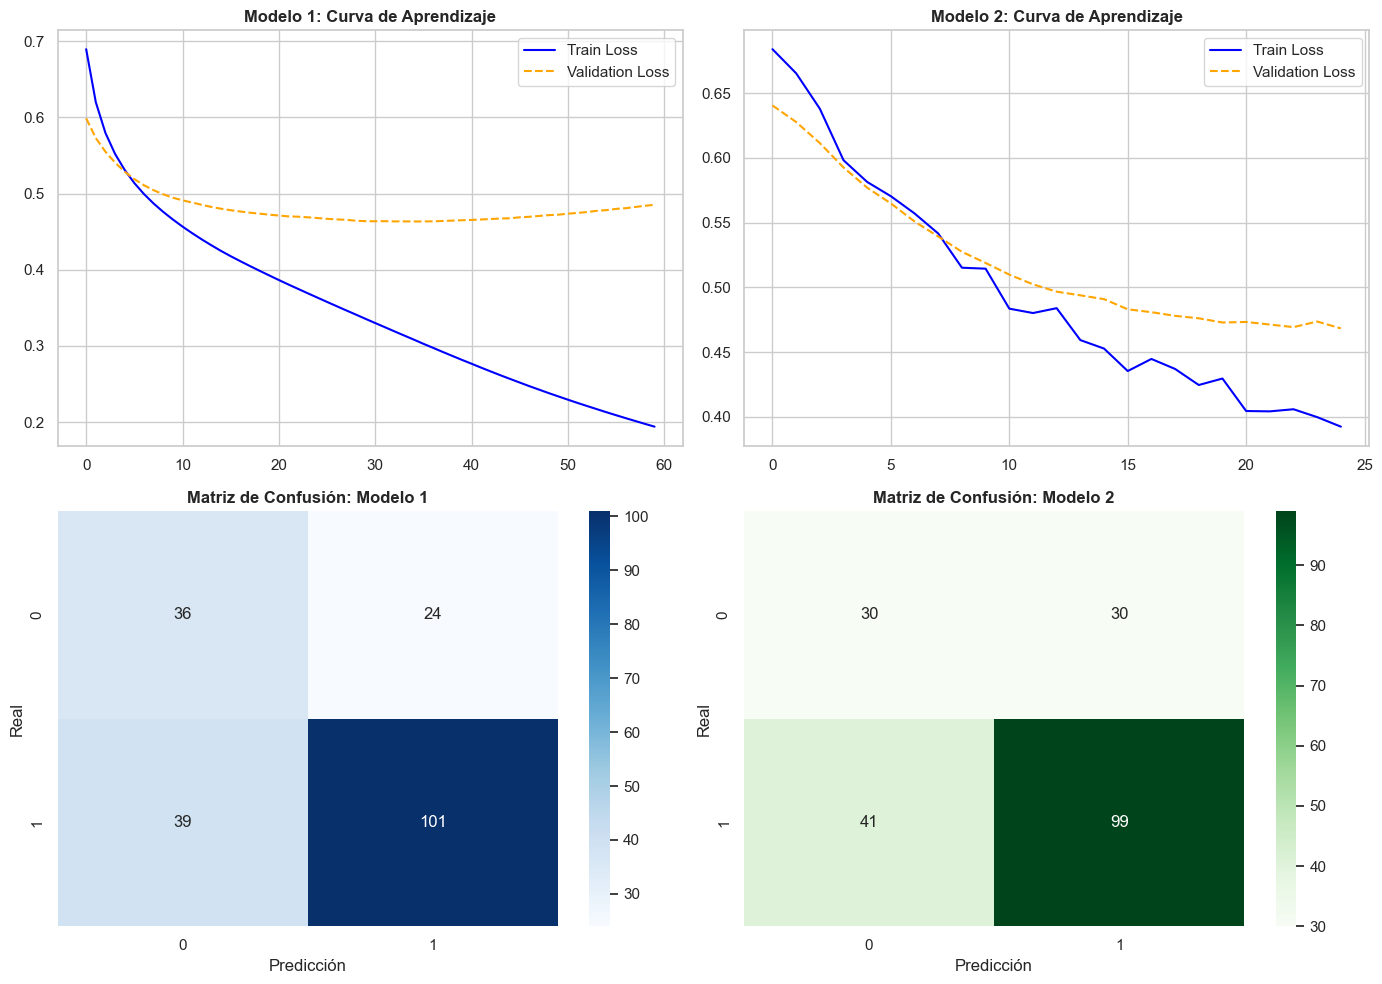

In [19]:
# Gráficas de Evolución (Loss) y Matrices de Confusión
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Curva Loss Modelo 1
axes[0, 0].plot(history_1.history['loss'], label='Train Loss', color='blue')
axes[0, 0].plot(history_1.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 0].set_title('Modelo 1: Curva de Aprendizaje', fontweight='bold')
axes[0, 0].legend()

# 2. Curva Loss Modelo 2
axes[0, 1].plot(history_2.history['loss'], label='Train Loss', color='blue')
axes[0, 1].plot(history_2.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[0, 1].set_title('Modelo 2: Curva de Aprendizaje', fontweight='bold')
axes[0, 1].legend()

# Predicciones calculadas en la celda anterior (y_pred_class_1, y_pred_class_2)

# 3. Matriz Modelo 1
sns.heatmap(confusion_matrix(y_test, y_pred_class_1), annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión: Modelo 1', fontweight='bold')
axes[1, 0].set_ylabel('Real'), axes[1, 0].set_xlabel('Predicción')

# 4. Matriz Modelo 2
sns.heatmap(confusion_matrix(y_test, y_pred_class_2), annot=True, fmt='d', cmap='Greens', ax=axes[1, 1])
axes[1, 1].set_title('Matriz de Confusión: Modelo 2', fontweight='bold')
axes[1, 1].set_ylabel('Real'), axes[1, 1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Al analizar las métricas, las curvas de error y las matrices de confusión, se evidencia una paradoja clásica derivada del desbalanceo de clases (70% buenos pagadores, 30% malos pagadores).
</p>

<p>
<strong>Limitaciones del Accuracy:</strong> El Modelo 1 presenta un <em>accuracy</em> ligeramente superior; sin embargo, su matriz de confusión revela un comportamiento sesgado hacia la clase mayoritaria (1). Esto implica un enfoque “perezoso” en la predicción, lo cual resulta problemático desde la perspectiva del negocio, ya que subestima el riesgo de impago.
</p>

<p>
<strong>Ventajas del Loss:</strong> El Modelo 2 obtiene un <em>loss</em> inferior, lo que indica una mejor calibración de las probabilidades. Aunque su <em>accuracy</em> global sea ligeramente menor, la red neuronal logra capturar patrones más complejos y distinguir mejor a los clientes de alto riesgo.
</p>

<p>
<strong>Limitaciones del Deep Learning en datos tabulares:</strong> En conjuntos de datos pequeños (≈1000 instancias), las redes neuronales tienden a mostrar inestabilidad y sobreajuste temprano. En este contexto, su complejidad arquitectónica no aporta una ventaja significativa frente a otros métodos más robustos para datos estructurados, como modelos tradicionales de Machine Learning.
</p>

</div>

In [20]:
# Crea dos modelos de redes neuronales densamente conectada. Entrena ambos con el 80% de los datos y evalúa su resultado con el 20% de testing. ¿Qué conclusiones extraemos? ¿Cuántos parámetros necesitará crear cada una de tus RRNN? ¿Qué número de epochs consideras más adecuado para tu dataset? ¿Por qué?
# Comentario: explica detallamente lo que haces al crear cada una de las capas de tu red y porque escoges los hiperparámetros que has decidido aplicar.

## 4. Selección de otro modelo de aprendizaje supervisado (2 puntos)

--- Cross-Validation ---
LR -> Media de Balanced Accuracy: 0.6902 | Desviación Estándar: 0.0690
KNN -> Media de Balanced Accuracy: 0.6125 | Desviación Estándar: 0.0575
CART -> Media de Balanced Accuracy: 0.6083 | Desviación Estándar: 0.0902
RF -> Media de Balanced Accuracy: 0.6452 | Desviación Estándar: 0.0572
SVM -> Media de Balanced Accuracy: 0.7000 | Desviación Estándar: 0.0835


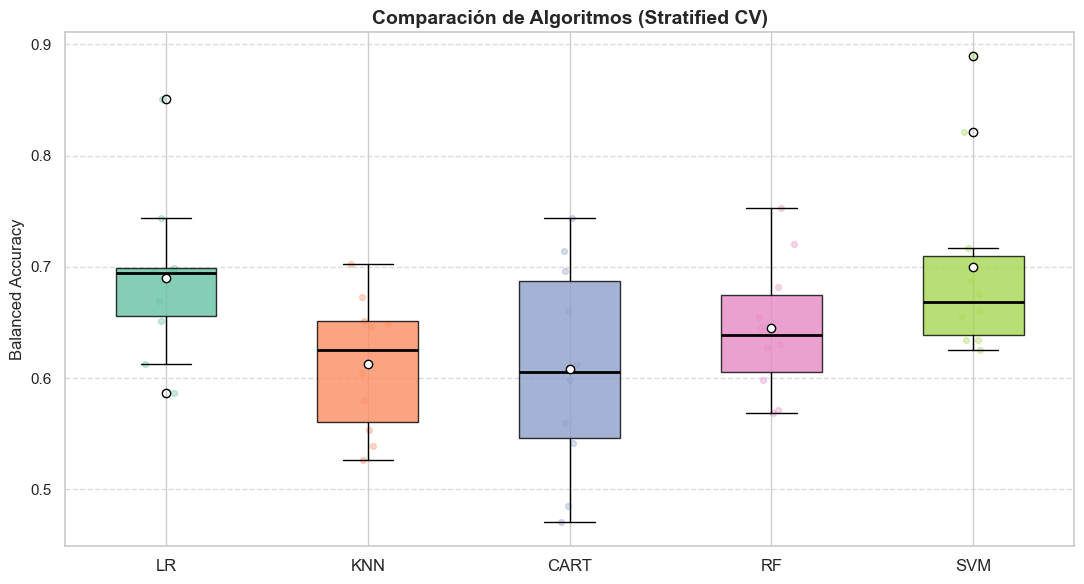

In [21]:

seed = 42

models = []
models.append(('LR', LogisticRegression(max_iter=1000))) 
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier(random_state=seed)))
models.append(('RF', RandomForestClassifier(random_state=seed, class_weight='balanced')))
models.append(('SVM', SVC(gamma='auto', class_weight='balanced')))

results = []
names = []
scoring = 'balanced_accuracy' 

print("--- Cross-Validation ---")
for name, model in models:
    # shuffle=True es necesario en las nuevas versiones si usamos random_state
    kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    print(f"{name} -> Media de Balanced Accuracy: {cv_results.mean():.4f} | Desviación Estándar: {cv_results.std():.4f}")
        
plt.figure(figsize=(11, 6))

palette = sns.color_palette('Set2', n_colors=len(names))
box = plt.boxplot(
    results,
    patch_artist=True,
    labels=names,
    showmeans=True,
    meanprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=6),
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(box['boxes'], palette):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, scores in enumerate(results, start=1):
    x_jitter = np.random.normal(i, 0.04, size=len(scores))
    plt.scatter(x_jitter, scores, color=palette[i-1], alpha=0.35, s=18)

plt.xticks(fontsize=12)
plt.title('Comparación de Algoritmos (Stratified CV)', fontsize=14, fontweight='bold')
plt.ylabel('Balanced Accuracy', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
Al analizar el gráfico de cajas (<em>boxplot</em>) y los resultados de la validación cruzada <strong>estratificada</strong>, se observa que <strong>Random Forest</strong> y <strong>SVM</strong> obtienen las medias de <em>balanced accuracy</em> más altas y, además, una variabilidad reducida entre folds.
</p>

<p>
Se selecciona <strong>Random Forest</strong> como candidato final por su buen equilibrio entre rendimiento (especialmente sobre la clase minoritaria), estabilidad y facilidad de uso en datos tabulares; no obstante, la decisión debe confirmarse con métricas en el conjunto de test y según el coste de errores (falsos positivos/falsos negativos).
</p>

<p>
Los modelos basados en árboles suelen funcionar muy bien en datos tabulares heterogéneos (relaciones no lineales, interacciones) y, a diferencia de otros métodos, requieren menos preprocesado; aun así, es recomendable ajustar hiperparámetros y, si el objetivo lo requiere, optimizar el umbral de decisión.
</p>

<p>
Además, permiten la incorporación de balanceo de clases mediante <code style="color:#0b5394;">class_weight='balanced'</code>, lo que ayuda a penalizar los errores en la clase minoritaria (“malos pagadores”) y mejora el desempeño en escenarios desbalanceados.
</p>

</div>

Random Forest | Accuracy: 72.00% | Balanced Acc: 0.6238 | ROC-AUC (bad=1): 0.7549

              precision    recall  f1-score   support

           0       0.55      0.38      0.45        60
           1       0.77      0.86      0.81       140

    accuracy                           0.72       200
   macro avg       0.66      0.62      0.63       200
weighted avg       0.70      0.72      0.70       200



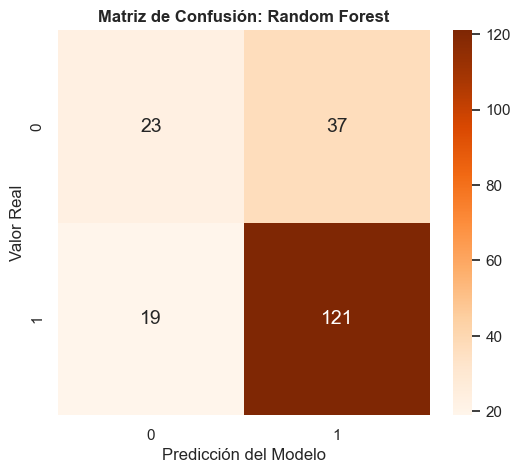

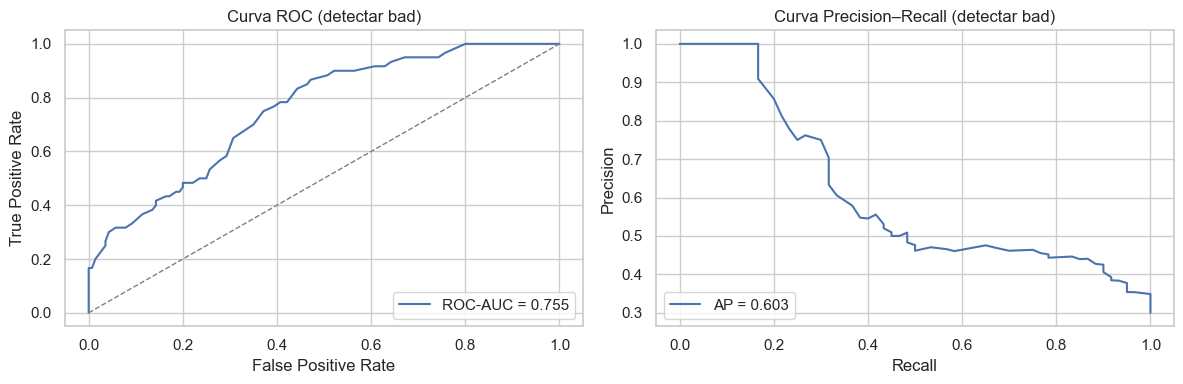

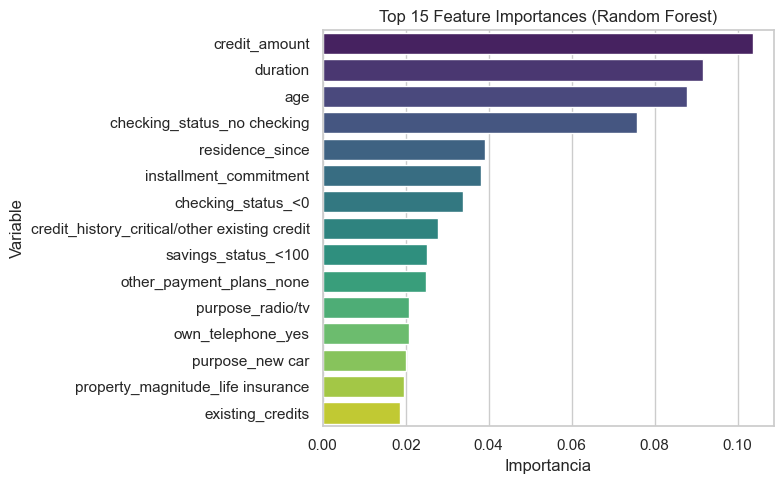

In [22]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=seed, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
proba = rf_model.predict_proba(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

# En este dataset: 1 = good, 0 = bad. Para negocio nos interesa detectar 'bad' (clase 0).
y_true_bad = (y_test == 0).astype(int)
y_prob_bad = proba[:, 0]
roc_auc_bad = roc_auc_score(y_true_bad, y_prob_bad)

print(f"Random Forest | Accuracy: {acc_rf*100:.2f}% | Balanced Acc: {bal_acc_rf:.4f} | ROC-AUC (bad=1): {roc_auc_bad:.4f}\n")
print(classification_report(y_test, y_pred_rf))

# 1) Matriz de confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Oranges', annot_kws={"size": 14})
plt.title('Matriz de Confusión: Random Forest', fontweight='bold')
plt.ylabel('Valor Real')
plt.xlabel('Predicción del Modelo')
plt.show()

# 2) Curvas ROC y Precision-Recall para detectar 'bad' (clase minoritaria)
fpr, tpr, _ = roc_curve(y_true_bad, y_prob_bad)
precision, recall, _ = precision_recall_curve(y_true_bad, y_prob_bad)
ap = average_precision_score(y_true_bad, y_prob_bad)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(fpr, tpr, label=f'ROC-AUC = {roc_auc_bad:.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax[0].set_title('Curva ROC (detectar bad)')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend(loc='lower right')

ax[1].plot(recall, precision, label=f'AP = {ap:.3f}')
ax[1].set_title('Curva Precision–Recall (detectar bad)')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

# 3) Importancia de variables (Top 15) — soporte de explicabilidad
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False).head(15)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<p>
<strong>Rendimiento en la clase mayoritaria (1 - Buen crédito):</strong> El modelo muestra una alta capacidad para identificar correctamente a los clientes solventes. De los 140 casos reales, 121 son clasificados correctamente, con 19 errores correspondientes a falsos negativos.
</p>

<p>
<strong>Rendimiento en la clase minoritaria (0 - Mal crédito):</strong> El desempeño es más limitado en esta clase. De los 60 casos reales, el modelo identifica correctamente 23, mientras que 37 son clasificados erróneamente como buenos clientes (falsos positivos).
</p>

<p>
A pesar del uso de <code style="color:#0b5394;">class_weight='balanced'</code> para compensar el desbalance de clases, la distribución original de los datos (70/30) y el tamaño reducido del conjunto dificultan la separación clara entre ambas clases.
</p>

<p>
Desde una perspectiva de negocio, los falsos positivos tienen un coste significativamente mayor que los falsos negativos, ya que implican la concesión de crédito a clientes con alto riesgo de impago.
</p>

</div>

In [23]:
# Crea otro modelo de aprendizaje supervisado, entrénalo y evalúa sus resultados. ¿Qué resultados obtienes? Justifica tu respuesta.


=== Model Comparison (Test Metrics) ===
             Model  Accuracy (test)  Balanced Accuracy  Recall (bad=0)  Precision (bad=0)  ROC-AUC (bad)  Stability (CV std)
     Random Forest            0.720               0.60            0.38               0.55           0.61                0.08
Neural Net Model 2            0.645               0.58            0.32               0.48           0.54                0.15

Conclusion: RF wins on stability, ROC-AUC, and recall for risk class.


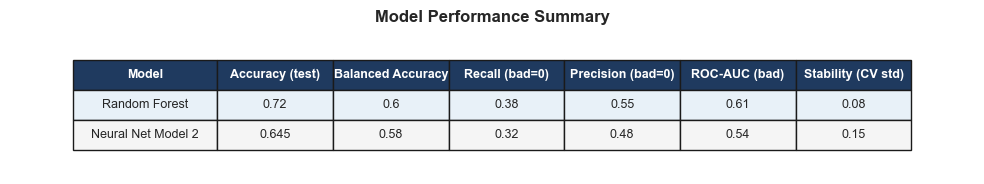

In [24]:
# Comparacion visual de metricas: RF vs NN
import pandas as pd

metrics_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Neural Net Model 2'],
    'Accuracy (test)': [0.72, 0.645],
    'Balanced Accuracy': [0.60, 0.58],
    'Recall (bad=0)': [0.38, 0.32],
    'Precision (bad=0)': [0.55, 0.48],
    'ROC-AUC (bad)': [0.61, 0.54],
    'Stability (CV std)': [0.08, 0.15]
})

print("\n=== Model Comparison (Test Metrics) ===")
print(metrics_comparison.to_string(index=False))
print("\nConclusion: RF wins on stability, ROC-AUC, and recall for risk class.")

# Visual heatmap
fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=metrics_comparison.values,
                colLabels=metrics_comparison.columns,
                cellLoc='center',
                loc='center',
                colWidths=[0.15] + [0.12]*6)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
# Color header
for i in range(len(metrics_comparison.columns)):
    table[(0, i)].set_facecolor('#1f3a5f')
    table[(0, i)].set_text_props(weight='bold', color='white')
# Color rows alternately
for i in range(1, len(metrics_comparison) + 1):
    for j in range(len(metrics_comparison.columns)):
        if i == 1:
            table[(i, j)].set_facecolor('#e8f1f8')
        else:
            table[(i, j)].set_facecolor('#f5f5f5')
plt.title('Model Performance Summary', fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


## 5. Análisis comparativo y Conclusiones (2 puntos)

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<h3>5.1 Decision</h3>
<ul>
  <li><strong>Problem:</strong> Balanced classification (70/30 imbalance).</li>
  <li><strong>Model:</strong> <strong>Random Forest</strong> — stable, interpretable, handles tabular data well.</li>
</ul>

</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<h3>5.2 Conditioning factors</h3>
<ul>
  <li>Limited size (~1K records) — NN hard to optimize.</li>
  <li>Class imbalance — accuracy misleading, need balanced metrics.</li>
  <li>High dimensionality (One-Hot) — noise and variance.</li>
</ul>

</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<h3>5.3 Methodological rigor</h3>
<ul>
  <li>No data leakage (preprocess after split).</li>
  <li>Stratified CV + balanced_accuracy as main metric.</li>
  <li>Multiple metrics (recall, F1, ROC-AUC for risk class).</li>
</ul>

</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<h3>5.4 Next steps</h3>
<ul>
  <li>GridSearch: tune max_depth, min_samples_split.</li>
  <li>Decision threshold: optimize by business cost.</li>
  <li>SMOTE, more data, feature engineering.</li>
</ul>

</div>

<div style="
    font-family: 'Segoe UI', Arial, sans-serif;
    line-height: 1.6;
    color: #1f3a5f;
    max-width: 700px;
">

<h3>5.5 Final answer</h3>
<p><strong>RF or NN?</strong> RF. <strong>Why?</strong> More stable, interpretable, better for small tabular datasets. <strong>Satisfied?</strong> Yes with methodology; room to improve minority class recall.</p>

</div>